# WoFS Rollout Visualization

This notebook focuses on two workflows:
- Rollout metrics CSV analysis and plotting by forecast step
- Prediction vs reference visualization with time-index multipanels
  - Choose variable from a dropdown
  - Show prediction, reference, and error side-by-side across multiple time indices

Update the paths in Cell 3 to point to your current run outputs.

In [1]:
from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

try:
    import ipywidgets as widgets
    from IPython.display import display
    HAS_WIDGETS = True
except Exception:
    HAS_WIDGETS = False

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True

In [17]:
# Update these paths for your run
metrics_path = Path('/scratch5/purged/Zhanxiang.Hua/credit_wofs_rollout_example/crossformer_det_epoch4/rollout_metrics.csv')
print('Metrics path exists :', metrics_path.exists(), metrics_path)


Metrics path exists : True /scratch5/purged/Zhanxiang.Hua/credit_wofs_rollout_example/crossformer_det_epoch4/rollout_metrics.csv


## 1) Rollout Metrics CSV

In [18]:
df = pd.read_csv(metrics_path)
print('Shape:', df.shape)
display(df.head(3))

id_candidates = ['case', 'forecast_step', 'forecast_period', 'rollout_index', 'sample_index', 'datetime']
id_cols = [c for c in id_candidates if c in df.columns]
metric_cols = [c for c in df.columns if c not in id_cols]

step_col = 'forecast_step' if 'forecast_step' in df.columns else ('forecast_hour' if 'forecast_hour' in df.columns else None)
print('ID columns      :', id_cols)
print('Metric columns  :', len(metric_cols))
print('Step axis column:', step_col)

# Parse metric columns of the form <metric>_<variable>, e.g. rmse_T2
metric_families = sorted({c.split('_', 1)[0] for c in metric_cols if '_' in c})
metric_variables = sorted({c.split('_', 1)[1] for c in metric_cols if '_' in c})

print('Metric families:', metric_families[:10], '... total=', len(metric_families))
print('Variables      :', metric_variables[:15], '... total=', len(metric_variables))

Shape: (2854, 457)


,case,forecast_step,forecast_period,rollout_index,sample_index,acc_T_0,rmse_T_0,mse_T_0,mae_T_0,acc_T_1,...,mse_W_UP_MAX,mae_W_UP_MAX,acc_LWP,rmse_LWP,mse_LWP,mae_LWP,acc,rmse,mse,mae
0,wofs_20210416_0000_mem01.zarr,1,1,1,0,0.999318,0.137048,0.018782,0.099793,0.999236,...,0.085820,0.176099,0.704036,420.296082,176648.812500,245.417557,0.880211,12.448359,2176.287354,8.846611
1,wofs_20210416_0000_mem01.zarr,2,2,2,1,0.998172,0.222612,0.049556,0.164066,0.997924,...,0.100165,0.183500,0.628456,445.513184,198481.984375,255.349823,0.838554,13.385018,2389.181641,9.473628
2,wofs_20210416_0000_mem01.zarr,3,3,3,2,0.996782,0.293773,0.086303,0.218882,0.996365,...,0.109955,0.182885,0.543355,480.072296,230469.406250,267.942932,0.809763,14.720418,2781.369141,10.472565


ID columns      : ['case', 'forecast_step', 'forecast_period', 'rollout_index', 'sample_index']
Metric columns  : 452
Step axis column: forecast_step
Metric families: ['acc', 'mae', 'mse', 'rmse'] ... total= 4
Variables      : ['COMPOSITE_REFL_10CM', 'GEOPOT_0', 'GEOPOT_1', 'GEOPOT_10', 'GEOPOT_11', 'GEOPOT_12', 'GEOPOT_13', 'GEOPOT_14', 'GEOPOT_15', 'GEOPOT_16', 'GEOPOT_2', 'GEOPOT_3', 'GEOPOT_4', 'GEOPOT_5', 'GEOPOT_6'] ... total= 112


In [19]:
def resolve_metric_column(metric_family: str, variable_name: str, available_cols: list[str]) -> str | None:
    target = f"{metric_family}_{variable_name}".lower()
    for c in available_cols:
        if c.lower() == target:
            return c
    return None

def plot_metric_by_step(df_in: pd.DataFrame, metric_family: str, variable_name: str, case_name: str | None = None):
    if step_col is None:
        print('No forecast step column found in CSV.')
        return

    col = resolve_metric_column(metric_family, variable_name, metric_cols)
    if col is None:
        print(f'Metric column not found for {metric_family}_{variable_name}')
        return

    d = df_in.copy()
    if case_name is not None and 'case' in d.columns:
        d = d[d['case'] == case_name]

    if d.empty:
        print('No rows available after filtering.')
        return

    y = d.groupby(step_col)[col].mean(numeric_only=True).sort_index()
    plt.figure(figsize=(11, 4))
    plt.plot(y.index, y.values, marker='o')
    plt.title(f'{col} vs {step_col}' + (f' (case={case_name})' if case_name else ' (mean across cases)'))
    plt.xlabel(step_col)
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

if HAS_WIDGETS and len(metric_cols) > 0:
    default_family = 'rmse' if 'rmse' in metric_families else metric_families[0]
    default_var = 'T2' if 'T2' in metric_variables else metric_variables[0]

    case_options = ['<ALL>']
    if 'case' in df.columns:
        case_options += sorted(df['case'].dropna().unique().tolist())

    metric_family_dd = widgets.Dropdown(options=metric_families, value=default_family, description='Metric:')
    metric_var_dd = widgets.Dropdown(options=metric_variables, value=default_var, description='Variable:')
    metric_case_dd = widgets.Dropdown(options=case_options, value='<ALL>', description='Case:')

    def update_plot(metric_family, variable_name, case_name):
        selected_case = None if case_name == '<ALL>' else case_name
        plot_metric_by_step(df, metric_family, variable_name, selected_case)

    ui = widgets.HBox([metric_family_dd, metric_var_dd, metric_case_dd])
    out = widgets.interactive_output(update_plot, {
        'metric_family': metric_family_dd,
        'variable_name': metric_var_dd,
        'case_name': metric_case_dd
    })

    display(ui, out)
else:
    print('ipywidgets unavailable or no metric columns found. Using defaults.')
    fallback_family = 'rmse' if 'rmse' in metric_families else (metric_families[0] if metric_families else None)
    fallback_var = 'T2' if 'T2' in metric_variables else (metric_variables[0] if metric_variables else None)
    if fallback_family and fallback_var:
        plot_metric_by_step(df, fallback_family, fallback_var)

Output()

## 2) Prediction vs Reference Multipanel

In [41]:
pred_case_path = Path('/scratch5/purged/Zhanxiang.Hua/credit_wofs_rollout_example/crossformer_det_epoch4/wofs_20210416_1700_mem01.zarr')
ref_case_path = Path('/scratch5/purged/Zhanxiang.Hua/wofs_preprocess_to_credit_0413/cases/wofs_20210416_1700_mem01.zarr.zip')
print('Pred case exists    :', pred_case_path.exists(), pred_case_path)
print('Ref  case exists    :', ref_case_path.exists(), ref_case_path)

Pred case exists    : True /scratch5/purged/Zhanxiang.Hua/credit_wofs_rollout_example/crossformer_det_epoch4/wofs_20210416_1700_mem01.zarr
Ref  case exists    : True /scratch5/purged/Zhanxiang.Hua/wofs_preprocess_to_credit_0413/cases/wofs_20210416_1700_mem01.zarr.zip


In [42]:
def open_case_dataset(path: Path):
    # Rollout outputs are usually standard zarr directories.
    if path.is_dir():
        return xr.open_zarr(path, consolidated=True)

    # Reference case may be .zarr.zip; fall back to credit.data loader if needed.
    if path.name.endswith('.zarr.zip') or path.suffix == '.zip':
        try:
            return xr.open_zarr(str(path))
        except Exception:
            from credit.data import get_forward_data
            return get_forward_data(str(path))

    if path.suffix == '.zarr':
        return xr.open_zarr(path, consolidated=True)

    raise ValueError(f'Unsupported dataset path: {path}')

pred_ds = open_case_dataset(pred_case_path)
pred_ds = pred_ds.isel(time=slice(None,-1))
ref_ds = open_case_dataset(ref_case_path)
ref_ds = ref_ds.isel(time=slice(1,None))

common_vars = sorted(set(pred_ds.data_vars).intersection(set(ref_ds.data_vars)))
print('Prediction dataset:')
print(pred_ds)
print('Reference dataset:')
print(ref_ds)
print(f'Common variables: {len(common_vars)}')
print(common_vars[:25])

Prediction dataset:
<xarray.Dataset> Size: 1GB
Dimensions:              (time: 36, latitude: 300, longitude: 300, level: 17)
Coordinates:
  * time                 (time) datetime64[ns] 288B 2021-04-16T17:10:00 ... 2...
    forecast_period      (time) int32 144B dask.array<chunksize=(36,), meta=np.ndarray>
    forecast_step        (time) int32 144B dask.array<chunksize=(36,), meta=np.ndarray>
  * latitude             (latitude) int64 2kB 0 1 2 3 4 ... 295 296 297 298 299
  * longitude            (longitude) int64 2kB 0 1 2 3 4 ... 295 296 297 298 299
  * level                (level) int64 136B 0 1 2 3 4 5 6 ... 11 12 13 14 15 16
Data variables: (12/16)
    COMPOSITE_REFL_10CM  (time, latitude, longitude) float32 13MB dask.array<chunksize=(10, 75, 150), meta=np.ndarray>
    GEOPOT               (time, level, latitude, longitude) float32 220MB dask.array<chunksize=(10, 5, 75, 75), meta=np.ndarray>
    LWP                  (time, latitude, longitude) float32 13MB dask.array<chunksize=(10, 

In [43]:
if len(common_vars) == 0:
    raise ValueError('No common variables between prediction and reference datasets.')

max_time_pred = int(pred_ds.sizes.get('time', 1)) - 1
max_time_ref = int(ref_ds.sizes.get('time', 1)) - 1
max_time = max(0, min(max_time_pred, max_time_ref))

default_var = 'COMPOSITE_REFL_10CM' if 'COMPOSITE_REFL_10CM' in common_vars else common_vars[0]

if HAS_WIDGETS:
    var_dropdown = widgets.Dropdown(
        options=common_vars,
        value=default_var,
        description='Variable:',
        layout=widgets.Layout(width='420px')
    )
    time_range = widgets.IntRangeSlider(
        value=(0, min(5, max_time)),
        min=0,
        max=max_time,
        step=1,
        description='Time idx:',
        continuous_update=False,
        layout=widgets.Layout(width='500px')
    )
    display(widgets.VBox([var_dropdown, time_range]))
    print('Select variable/time range, then run the next cell to render multipanel plots.')
else:
    selected_var = default_var
    selected_t0 = 0
    selected_t1 = min(5, max_time)
    print('ipywidgets not available, using fallback selections.')

Select variable/time range, then run the next cell to render multipanel plots.


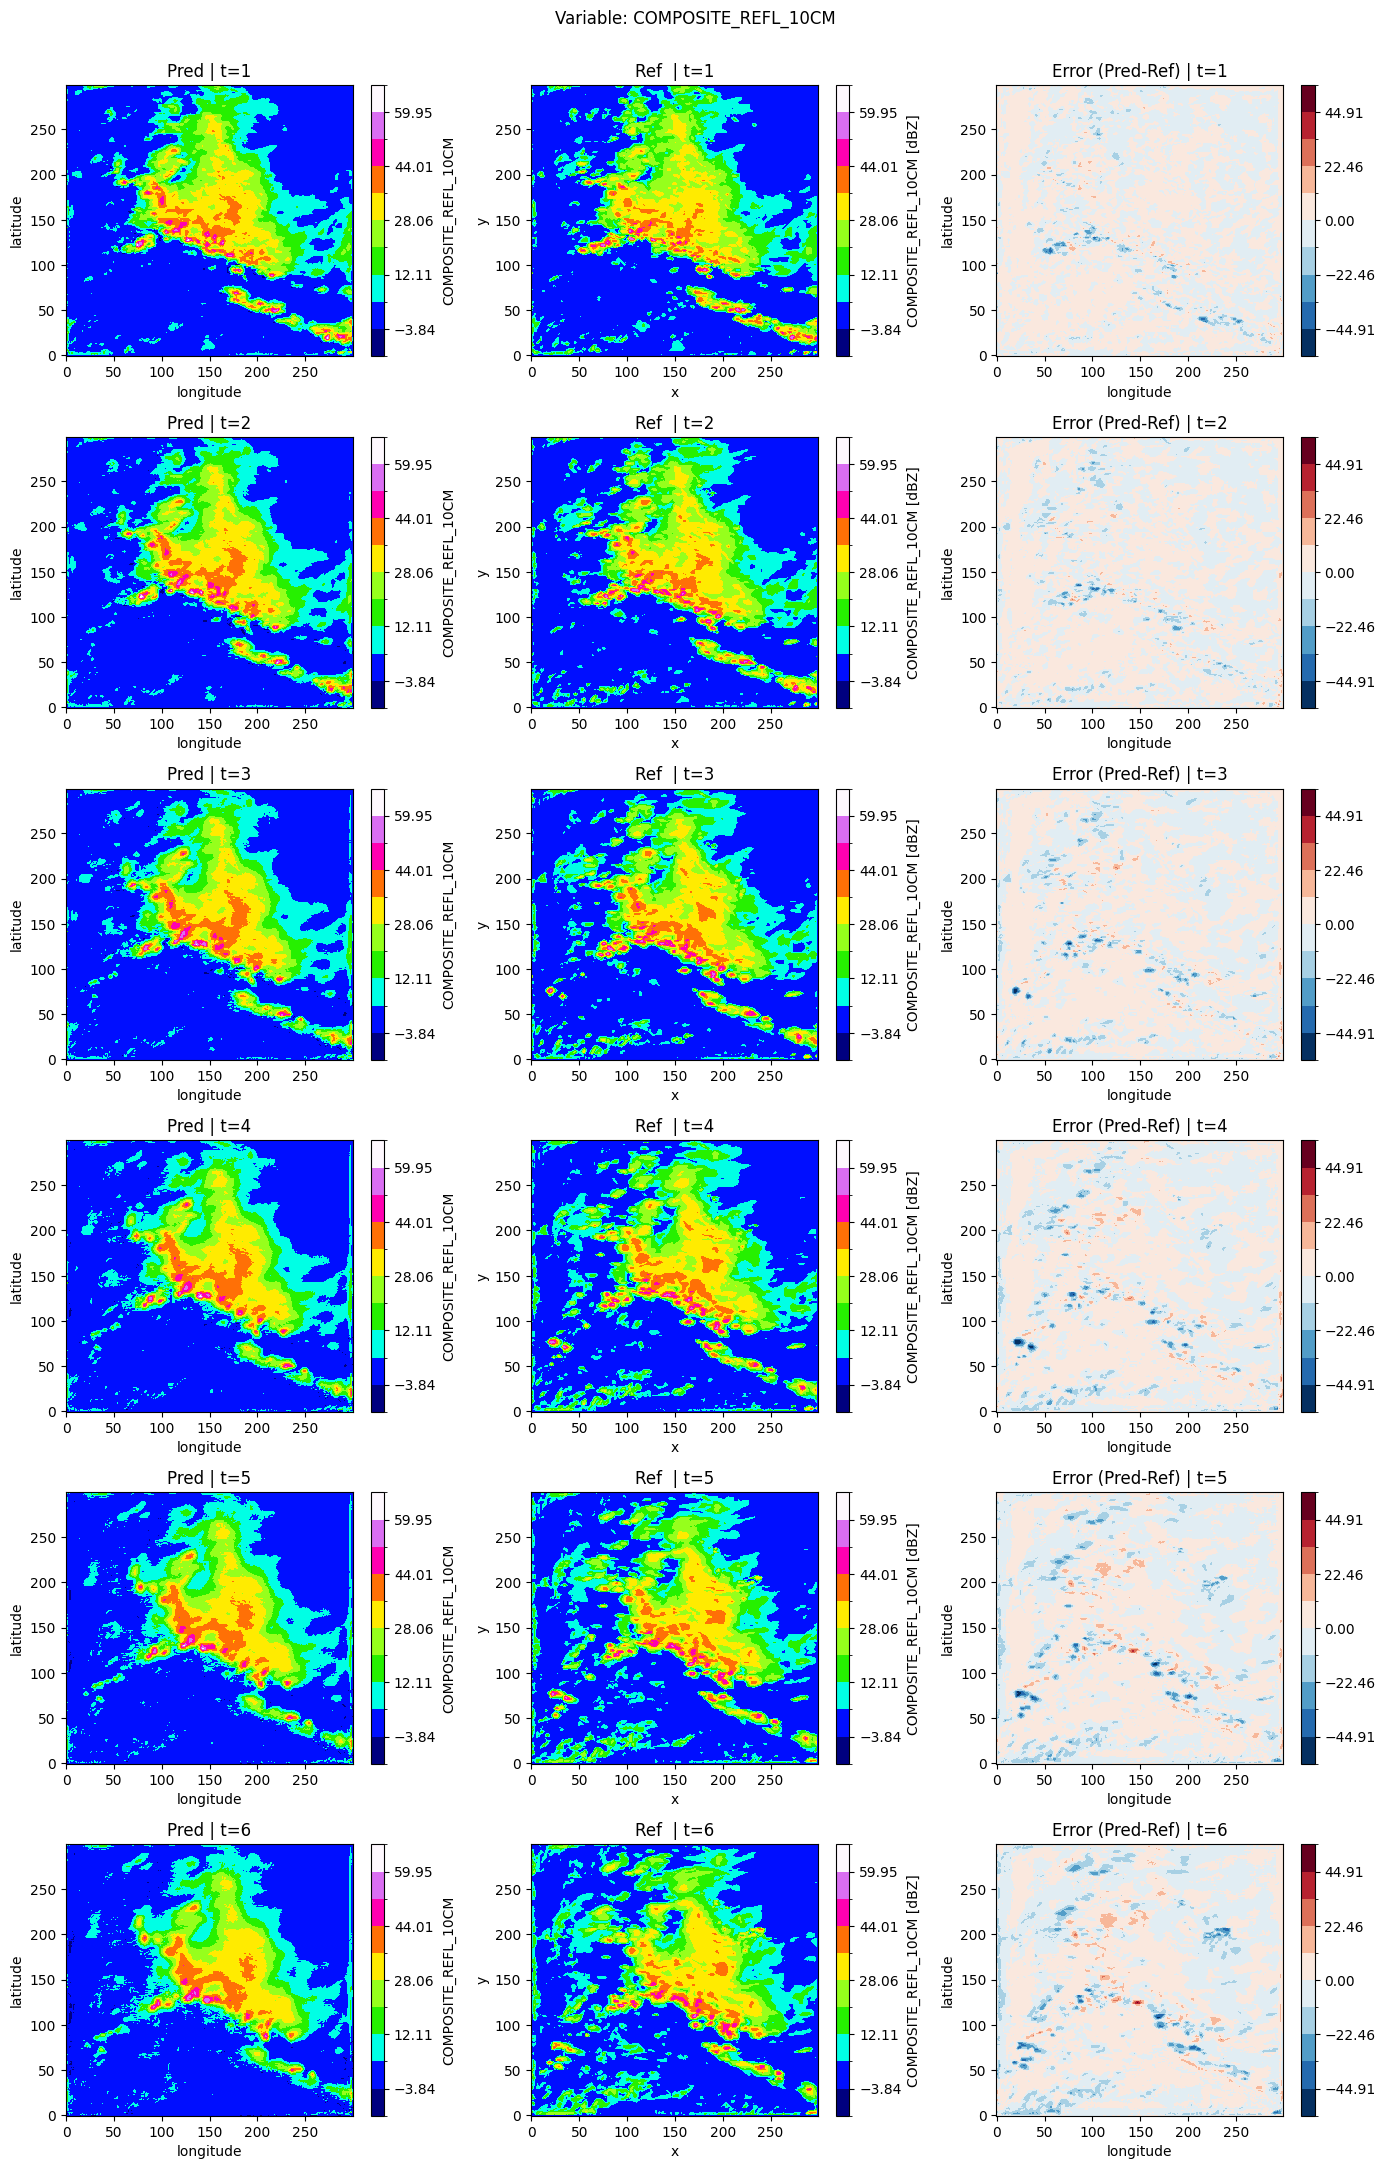

In [44]:
import matplotlib.colors as mcolors

def pick_2d_frame(da: xr.DataArray, time_idx: int):
    x = da
    if 'time' in x.dims:
        x = x.isel(time=min(time_idx, int(x.sizes['time']) - 1))

    if x.ndim > 2:
        if 'level' in x.dims:
            x = x.isel(level=0)
        elif 'lev' in x.dims:
            x = x.isel(lev=0)

    while x.ndim > 2:
        x = x.isel({x.dims[0]: 0})

    return x.squeeze().load()

def plot_pred_ref_multipanel(pred_ds, ref_ds, var_name: str, t0: int, t1: int):
    time_ids = list(range(t0, t1 + 1))
    if len(time_ids) == 0:
        print('No time indices selected.')
        return

    pred_frames = [pick_2d_frame(pred_ds[var_name], t) for t in time_ids]
    ref_frames = [pick_2d_frame(ref_ds[var_name], t) for t in time_ids]

    pred_stack = np.stack([np.asarray(a.values) for a in pred_frames])
    ref_stack = np.stack([np.asarray(a.values) for a in ref_frames])
    err_stack = pred_stack - ref_stack

    data_min = float(np.nanmin([pred_stack.min(), ref_stack.min()]))
    data_max = float(np.nanmax([pred_stack.max(), ref_stack.max()]))
    err_abs = float(np.nanmax(np.abs(err_stack)))
    err_abs = max(err_abs, 1e-12)
    n_bins=10
    n = len(time_ids)
    # Define discrete levels
    data_levels = np.linspace(data_min, data_max, n_bins + 1)
    err_levels = np.linspace(-err_abs, err_abs, n_bins + 1)
    
    data_norm = mcolors.BoundaryNorm(data_levels, ncolors=plt.get_cmap('gist_ncar').N)
    err_norm = mcolors.BoundaryNorm(err_levels, ncolors=plt.get_cmap('RdBu_r').N)

    fig, axes = plt.subplots(nrows=n, ncols=3, figsize=(14, 3.6 * n), squeeze=False)

    for i, t in enumerate(time_ids):
        p = pred_frames[i]
        r = ref_frames[i]
        e = xr.DataArray(
            err_stack[i],
            dims=p.dims,
            coords={d: p.coords[d] for d in p.dims if d in p.coords},
        )
    
        p.plot(
            ax=axes[i, 0],
            cmap='gist_ncar',
            norm=data_norm,
            add_colorbar=True
        )
        axes[i, 0].set_title(f'Pred | t={t+1}')
    
        r.plot(
            ax=axes[i, 1],
            cmap='gist_ncar',
            norm=data_norm,
            add_colorbar=True
        )
        axes[i, 1].set_title(f'Ref  | t={t+1}')
    
        e.plot(
            ax=axes[i, 2],
            cmap='RdBu_r',
            norm=err_norm,
            add_colorbar=True
        )
        axes[i, 2].set_title(f'Error (Pred-Ref) | t={t+1}')

    plt.suptitle(f'Variable: {var_name}', y=1.002)
    plt.tight_layout()
    plt.show()

if HAS_WIDGETS and 'var_dropdown' in globals():
    var_name = var_dropdown.value
    t0, t1 = time_range.value
else:
    var_name = selected_var
    t0, t1 = selected_t0, selected_t1

plot_pred_ref_multipanel(pred_ds, ref_ds, var_name, int(t0), int(t1))

In [45]:
ds = xr.open_zarr('/scratch5/purged/Zhanxiang.Hua/credit_wofs_rollout_example/ens/wofs_20210416_1700_mem01.zarr')

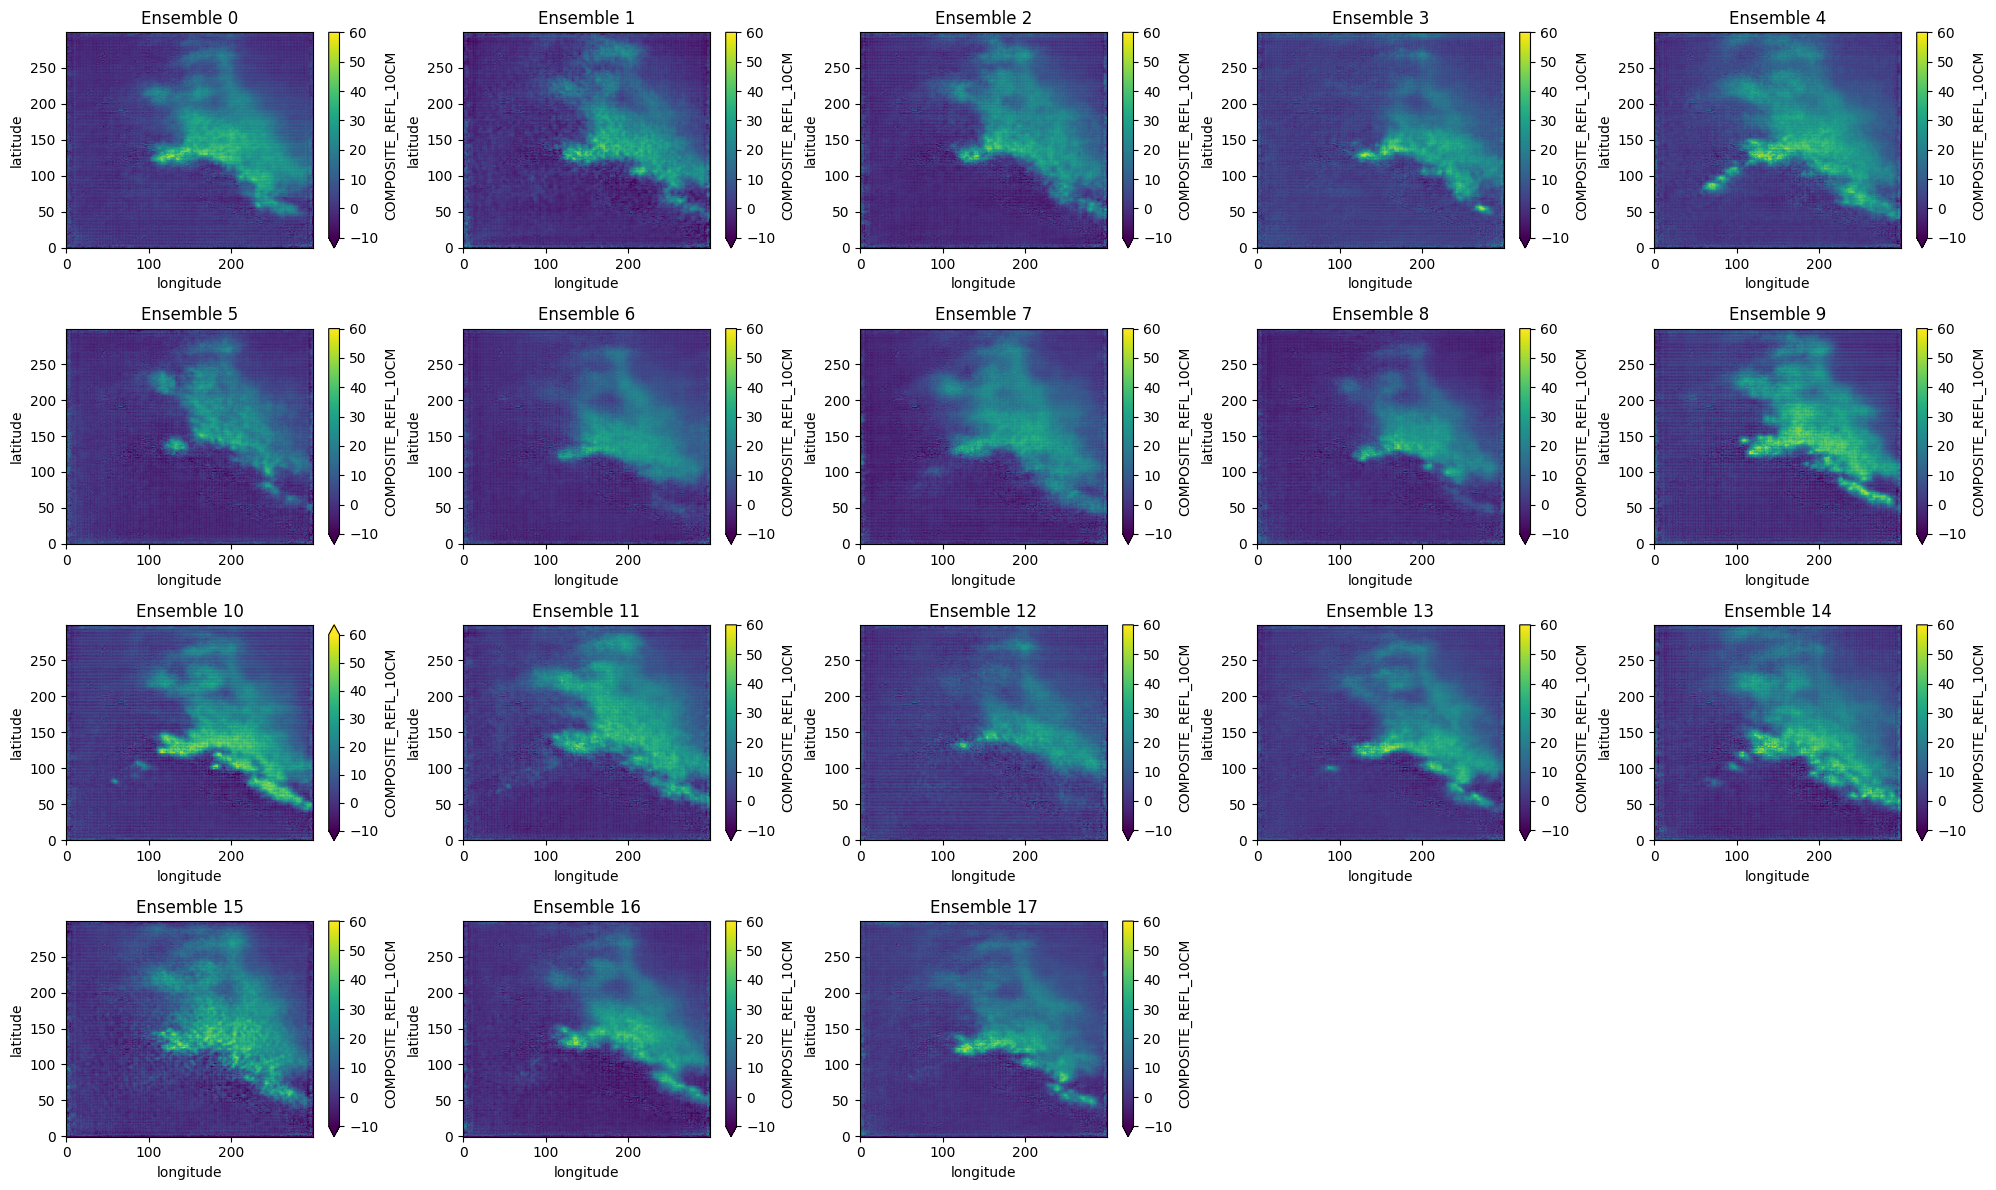

In [46]:
import matplotlib.pyplot as plt
import numpy as np

# Suppose ds is your xarray Dataset
ensemble_members = ds.ensemble_member_label.values  # all ensemble members
n_members = len(ensemble_members)

# Determine grid size (square-ish)
n_cols = int(np.ceil(np.sqrt(n_members)))
n_rows = int(np.ceil(n_members / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axes = axes.flatten()  # flatten for easy indexing

for i, member in enumerate(ensemble_members):
    ds.isel(ensemble_member_label=i, time=15)['COMPOSITE_REFL_10CM'].plot(
        ax=axes[i], cmap='viridis', vmin=-10, vmax=60
    )
    axes[i].set_title(f'Ensemble {member}')

# Turn off unused axes if any
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()